### Import libraries

In [5]:
import warnings

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import nnls
from scipy.stats import norm
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")

### Custom functions

In [6]:
# --- Option risk ---
def bs(S, K, T, sigma, is_call):
    """Black-Scholes price and delta (r = 0)."""
    sd = sigma * np.sqrt(T)
    d1 = np.log(S / K) / sd + sd / 2
    call = S * norm.cdf(d1) - K * norm.cdf(d1 - sd)
    return np.where(is_call, call, call - S + K), norm.cdf(d1) - ~is_call


def unit_risk(K, is_call, S, T, sigma, shocks=(-0.05, -0.10)):
    """t0 risk of one unit of each option: gamma cash, theta (per day), vega (per vol point), delta hedged slides."""
    sd = sigma * np.sqrt(T)
    pdf = norm.pdf(np.log(S / K) / sd + sd / 2)
    price, delta = bs(S, K, T, sigma, is_call)
    risk = {"gamma_cash": pdf * S / sd / 100, "theta": -S * pdf * sigma / (2 * np.sqrt(T)) / 252, "vega": S * pdf * np.sqrt(T) / 100}
    for x in shocks:
        risk[f"slide_{x:+.0%}"] = bs(S * (1 + x), K, T, sigma, is_call)[0] - price - delta * S * x
    return pd.DataFrame(risk)


# --- Solver helpers ---
def _qr(X, y):
    """||y - X w||^2 = ||z - R w||^2 + const on scaled data, and the R2 of weights w."""
    s = np.sqrt(np.mean(y ** 2))
    q, R = np.linalg.qr(X.to_numpy() / s)
    ys = y.to_numpy() / s
    z = q.T @ ys
    sse_perp, sst = ys @ ys - z @ z, ((ys - ys.mean()) ** 2).sum()
    return R, z, lambda w: 1 - (((z - R @ w) ** 2).sum() + sse_perp) / sst


def _constraints(w, cols, risk, floors, bands):
    """reduced >= ratio * full for floors, |reduced - full| <= tol * |full| for bands (relative to |full|)."""
    full = risk.sum()
    rel = {m: risk.loc[cols, m].to_numpy() / abs(full[m]) @ w - np.sign(full[m]) for m in [*floors, *bands]}
    return ([rel[m] + (1 - k) * np.sign(full[m]) >= 0 for m, k in floors.items()]
            + [cp.abs(rel[m]) <= tol for m, tol in bands.items()])


def _solve(problem, w):
    """Solved weights with solver zeros cleaned, or None if infeasible."""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            problem.solve(solver=cp.CLARABEL)
    except cp.SolverError:
        return None
    if problem.status not in ("optimal", "optimal_inaccurate"):
        return None
    w = np.maximum(w.value, 0.0)
    w[w < 1e-6 * w.max()] = 0.0
    return w


# --- Solvers: multipliers w >= 0 of X's columns (full book = 1) tracking y under risk constraints ---
def lasso(X, y, risk, max_n, floors, bands, eps_scale=0.5, n_iter=10, n_grid=30, n_refine=15):
    """Iteratively reweighted long-only lasso, alpha = best fit with <= max_n positions on a refined log grid."""
    n, p = X.shape
    R, z, r2 = _qr(X, y)
    w, pen = cp.Variable(p, nonneg=True), cp.Parameter(p, nonneg=True)
    problem = cp.Problem(cp.Minimize(cp.sum_squares(R @ w - z) / (2 * n) + pen @ w), _constraints(w, X.columns, risk, floors, bands))

    def fit(alpha, strike_pen):
        pen.value = alpha * strike_pen
        c = _solve(problem, w)
        return None if c is None else {"alpha": alpha, "n": (c > 0).sum(), "r2": r2(c), "w": c}

    def fits(alphas, strike_pen):
        return [f for a in alphas if (f := fit(a, strike_pen))]

    def best_alpha(strike_pen):
        top = (R.T @ z / n / strike_pen).max()
        grid = fits(np.geomspace(top, top * 1e-4, n_grid), strike_pen)
        best = max([f for f in grid if f["n"] <= max_n] or [min(grid, key=lambda f: f["n"])], key=lambda f: f["r2"])
        if smaller := [f["alpha"] for f in grid if f["alpha"] < best["alpha"]]:
            refined = fits(np.geomspace(best["alpha"], smaller[0], n_refine), strike_pen)
            best = max([best, *[f for f in refined if f["n"] <= max_n]], key=lambda f: f["r2"])
        return best

    strike_pen, best = np.ones(p), None
    for _ in range(n_iter):
        f = best_alpha(strike_pen)
        if f["n"] <= max_n and (best is None or f["r2"] > best["r2"]):
            best = f
        strike_pen = 1 / (f["w"] + eps_scale * f["w"][f["w"] > 0].mean())
    return best["w"], best["r2"]


def omp(X, y, risk, max_n, floors, bands, n_candidates=20):
    """Long-only OMP selection, then constrained least squares with swaps until no swap improves the fit."""
    p = X.shape[1]
    R, z, r2 = _qr(X, y)

    def expand(sel, c):
        w = np.zeros(p)
        w[sel] = c
        return w

    def constrained_fit(sel):
        w = cp.Variable(len(sel), nonneg=True)
        c = _solve(cp.Problem(cp.Minimize(cp.sum_squares(R[:, sel] @ w - z)), _constraints(w, X.columns[sel], risk, floors, bands)), w)
        return None if c is None else expand(sel, c)

    def screened(w, sel):
        return [j for j in np.argsort(-(R.T @ (z - R @ w))) if j not in sel][:n_candidates]

    sel, w = [], np.zeros(p)
    for _ in range(max_n):
        w, j = max(((expand([*sel, j], nnls(R[:, [*sel, j]], z)[0]), j) for j in screened(w, sel)), key=lambda t: r2(t[0]))
        sel.append(j)

    best = constrained_fit(sel)
    best_r2, improved = (-np.inf if best is None else r2(best)), True
    while improved:
        improved = False
        for i in range(len(sel)):
            for j in screened(w if best is None else best, sel):
                trial = [*sel[:i], j, *sel[i + 1:]]
                c = constrained_fit(trial)
                if c is not None and r2(c) > best_r2 + 1e-9:
                    sel, best, best_r2, improved = trial, c, r2(c), True
    w = w if best is None else best
    return w, r2(w)


# --- Terminal payoff reduction ---
def _quick_terminal_payoff(solver, portfolio_weight, option_terminal_payoff, risk_t0, risk_floor, risk_tolerance,
                           max_position=10, option_bid_offer=None, pnl_haircut=None):
    """Reduces the portfolio to <= max_position options tracking its terminal payoff under t0 risk constraints.
    Optional bid-offer floor: sum(reduced * option_bid_offer) >= pnl_haircut * sum(portfolio * option_bid_offer).
    Returns (reduced quantities, r2, risk_check)."""
    floors = dict.fromkeys(risk_floor, 1.0)
    if option_bid_offer is not None:
        risk_t0, floors["bid_offer"] = risk_t0.assign(bid_offer=option_bid_offer), pnl_haircut
    names = portfolio_weight.index
    X = option_terminal_payoff[names] * portfolio_weight
    w, r2 = solver(X, X.sum(axis=1), risk_t0.loc[names].mul(portfolio_weight, axis=0), max_position, floors, risk_tolerance)
    reduced = (portfolio_weight * w)[w > 0]

    check = pd.DataFrame({"portfolio": risk_t0.loc[names].T @ portfolio_weight, "reduced": risk_t0.loc[reduced.index].T @ reduced})
    check["diff"] = check["reduced"] - check["portfolio"]
    tol = 1e-5 * check["portfolio"].abs()
    check["ok"] = pd.Series({m: check.loc[m, "reduced"] - k * check.loc[m, "portfolio"] >= -tol[m] for m, k in floors.items()}
                            | {m: abs(check.loc[m, "diff"]) <= t * abs(check.loc[m, "portfolio"]) + tol[m] for m, t in risk_tolerance.items()},
                            dtype=object)
    return reduced, r2, check


def quick_terminal_payoff_lasso(*args, **kwargs):
    return _quick_terminal_payoff(lasso, *args, **kwargs)


def quick_terminal_payoff_omp(*args, **kwargs):
    return _quick_terminal_payoff(omp, *args, **kwargs)

### Example portfolio

In [7]:
# Variance swap like portfolio: 60 puts / calls with quantity ~ 1 / K^2
S0, T, sigma = 100.0, 60 / 252, 0.20
strikes = np.linspace(75, 130, 60)
is_call = strikes >= S0
names = [f"{'call' if c else 'put'}_{k:.1f}" for k, c in zip(strikes, is_call)]
portfolio_weight = pd.Series(1e7 / strikes ** 2, index=names)

# Unit terminal payoffs on Monte Carlo spots, unit t0 risks and a bid-offer cost growing away from the money
rng = np.random.default_rng(42)
spots = S0 * np.exp(sigma * np.sqrt(T) * rng.standard_normal(5_000) - sigma ** 2 * T / 2)
option_terminal_payoff = pd.DataFrame(np.where(is_call, np.maximum(spots[:, None] - strikes, 0), np.maximum(strikes - spots[:, None], 0)),
                                      index=spots, columns=names)
risk_t0 = unit_risk(strikes, is_call, S0, T, sigma).set_axis(names)
option_bid_offer = pd.Series(-0.01 * (strikes - S0) ** 2, index=names)

### Strike reduction: lasso vs OMP

Lasso: R2 = 99.8065%


,quantity
put_84.3,14_888
put_91.8,6_309
put_94.6,4_505
put_99.2,2_582
call_100.2,1_211
call_103.9,7_320
call_113.2,7_879
call_120.7,5_488


,portfolio,reduced,diff,ok
gamma_cash,106_814,106_814,-0.007532,True
theta,-847.7,-847.7,5.978e-05,True
vega,5_086,5_086,-0.0003587,True
slide_-5%,13_811,13_837,26.04,True
slide_-10%,57_096,57_096,-0.003791,True
bid_offer,-158_619,-80_546,78_073,True


OMP: R2 = 99.8971%


,quantity
put_83.4,13_035
put_89.0,5_695
put_93.6,7_397
put_99.2,2_918
call_101.1,3_977
call_106.7,5_964
call_113.2,6_177
call_122.5,7_756


,portfolio,reduced,diff,ok
gamma_cash,106_814,106_814,-1.659e-09,True
theta,-847.7,-847.7,1.307e-11,True
vega,5_086,5_086,-7.913e-11,True
slide_-5%,13_811,13_828,17.25,True
slide_-10%,57_096,57_096,3.178e-08,True
bid_offer,-158_619,-98_811,59_809,True


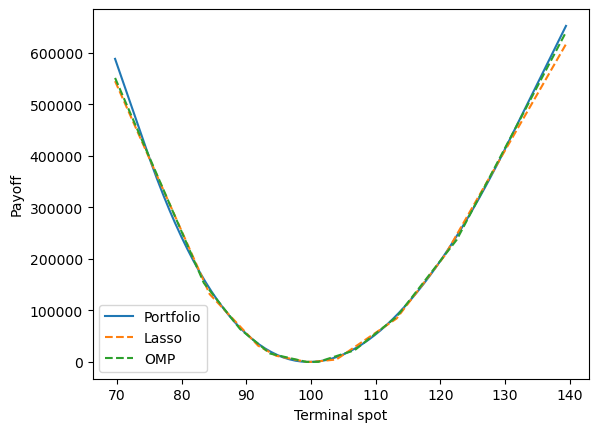

In [8]:
kwargs = dict(risk_floor=["gamma_cash", "theta", "slide_-5%", "slide_-10%"], risk_tolerance={"vega": 0.05},
              max_position=8, option_bid_offer=option_bid_offer, pnl_haircut=0.8)
results = {"Lasso": quick_terminal_payoff_lasso(portfolio_weight, option_terminal_payoff, risk_t0, **kwargs),
           "OMP": quick_terminal_payoff_omp(portfolio_weight, option_terminal_payoff, risk_t0, **kwargs)}

grid = np.sort(spots)
plt.plot(grid, option_terminal_payoff.loc[grid] @ portfolio_weight, label="Portfolio")
for method, (reduced, r2, check) in results.items():
    print(f"{method}: R2 = {r2:.4%}")
    display(reduced.to_frame("quantity"), check)
    plt.plot(grid, option_terminal_payoff.loc[grid, reduced.index] @ reduced, "--", label=method)
plt.xlabel("Terminal spot")
plt.ylabel("Payoff")
plt.legend()
plt.show()